# Caso De Estudio: Peru Bank - Deposito a Plazo

Atibutos: Edad, Saldo_Anual, Nivel_Educativo (0-2)   
Target: Contrata_Deposito (0:No, 1: Si)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
np.random.seed(42)
data_size = 500
X = np.random.rand(data_size, 3)

X[:, 0] = X[:, 0]*60 + 18  # Col1: Edad entre 18 y 78
X[:, 1] = X[:, 1]*10000
X[:, 2] = np.random.randint(0, 3, data_size)

In [6]:
y = (X[:, 0] * 0.5 + X[:, 1]*0.002 + X[:, 2]*5 > 35).astype(int)

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3)

In [9]:
mlp = MLPClassifier(hidden_layer_sizes=(5, 3), max_iter=1000, random_state=1)

In [10]:
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(5, 3), max_iter=1000, random_state=1)

In [11]:
y_pred = mlp.predict(X_test)

In [12]:
cm = confusion_matrix(y_test, y_pred)

<function matplotlib.pyplot.show(close=None, block=None)>

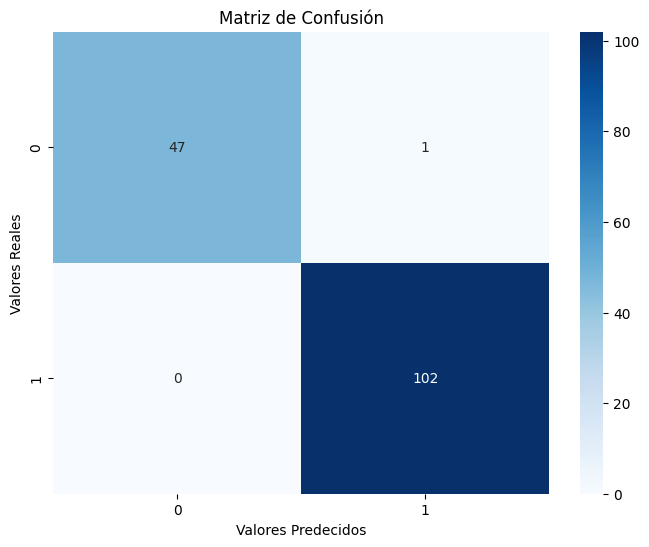

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predecidos')
plt.show